# Designs over dials

Tutorial 07 designs over **parts** — which −35 box, which spacer — because that is
what a construct is made of. This one designs over quantities you can genuinely
set to any value in a range: temperature, inducer concentration, pH, feed rate,
induction time, medium component.

The distinction matters more than it looks. A continuous optimiser will return
`promoter = 0.672`, and there is no such promoter; the same optimiser returning
`IPTG = 0.34 mM` is giving you something you can pipette. Use the continuous
machinery for the things that are continuous, and the discrete machinery
(tutorial 07) for the things that come out of a freezer box.

In [1]:
import numpy as np

import omicverse as ov
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — How many experiments?

The designs trade different things away, and the trade is the whole point: a
round costs weeks.

In [2]:
factors = {'temperature': (25.0, 37.0), 'iptg_mM': (0.01, 1.0), 'od_at_induction': (0.2, 1.2)}
for name in ('full_factorial', 'fractional_factorial', 'plackett_burman',
             'definitive_screening', 'central_composite', 'box_behnken'):
    design = ov.synbio.doe_design(factors, design=name)
    print(f'  {name:22s} {design.n_runs:3d} runs')

  full_factorial           8 runs
  fractional_factorial     8 runs
  plackett_burman          4 runs
  definitive_screening     7 runs
  central_composite       17 runs
  box_behnken             15 runs


With three factors the full factorial is only 8 runs, so nothing is saved. The
argument appears at eight factors:

In [3]:
eight = {f'x{i}': (0.0, 1.0) for i in range(8)}
for name in ('full_factorial', 'fractional_factorial', 'plackett_burman', 'definitive_screening'):
    print(f'  {name:22s} {ov.synbio.doe_design(eight, design=name).n_runs:4d} runs')

  full_factorial          256 runs
  fractional_factorial     16 runs
  plackett_burman          16 runs
  definitive_screening     17 runs


**256 runs against 16.** Resolution IV is what makes those 16 interpretable: main
effects stay unconfounded with two-factor interactions, so the ranking that comes
out means something. Plackett-Burman is cheaper still and confounds them
completely — fine when you only want to know which factors matter at all.

A definitive screening design costs 2k+1 and additionally makes curvature
estimable, so a quadratic optimum shows up in round one instead of being
discovered later.

## 2 — The design matrix, in units you can set

Always look at the natural units, not just the coded ones.

In [4]:
design = ov.synbio.doe_design(factors, design='central_composite')
print(design)
print(design.to_frame().round(3).to_string())

Design(central_composite, 17 runs, 3 factors)
       temperature  iptg_mM  od_at_induction
run1        27.432    0.211            0.403
run2        27.432    0.211            0.997
run3        27.432    0.799            0.403
run4        27.432    0.799            0.997
run5        34.568    0.211            0.403
run6        34.568    0.211            0.997
run7        34.568    0.799            0.403
run8        34.568    0.799            0.997
run9        25.000    0.505            0.700
run10       37.000    0.505            0.700
run11       31.000    0.010            0.700
run12       31.000    1.000            0.700
run13       31.000    0.505            0.200
run14       31.000    0.505            1.200
run15       31.000    0.505            0.700
run16       31.000    0.505            0.700
run17       31.000    0.505            0.700


Every row is a setting you could dial in: no negative concentrations, nothing
outside the range that was asked for.

That is a fix rather than a given. The rotatable α for three factors is 1.682,
and `to_frame()` maps coded ±1 onto the stated bounds — so the axial points land
**1.68× outside the range the caller declared**. Over `(1, 20)` plasmid copies
that produced −5.5 and 26.5 copies, and 6 of 17 runs fell outside the bounds. The
design is now rescaled so the axial points sit *on* the bounds, which preserves
the relative geometry and therefore rotatability.

In [5]:
unbounded = ov.synbio.doe_design(factors, design='central_composite', bounded=False).to_frame()
print('classic (unscaled) axial points:')
print(unbounded.agg(['min', 'max']).round(3).to_string())
print('\nrequested bounds:', factors)

classic (unscaled) axial points:
     temperature  iptg_mM  od_at_induction
min       20.909   -0.327           -0.141
max       41.091    1.337            1.541

requested bounds: {'temperature': (25.0, 37.0), 'iptg_mM': (0.01, 1.0), 'od_at_induction': (0.2, 1.2)}


`bounded=False` is kept for anyone who wants the textbook form, and it is
honest about what it does.

## 3 — A response, and effects

We need a response with real structure. The σ70 promoter library gives one: take
the measured expression of each variant and treat three sequence elements as if
they were dials, which is exactly the modelling error this notebook is about — so
here we do it deliberately and on a design where it is legitimate, by using a
**genuine continuous** response built from measured data.

In [6]:
library = ov.synbio.fetch_promoter_library()
by_element = library.groupby('minus35')['log2_expression'].mean().sort_values()
print(by_element.round(3).to_string())

minus35
35T->C/33G->C/31C->G   -2.431
35T->C/33G->T/31G->C   -2.373
33G->A/31C->G          -2.269
35T->A/33G->T          -2.222
34G->T/30A->C          -1.536
34G->T                 -0.695
32A->C/31C->A          -0.349
consensus35             0.757


Rank those eight −35 boxes from weakest to strongest and you have a genuinely
ordered scale. A design over "−35 strength rank", "spacer rank" and "−10 rank" is
a design over three quantities that *are* ordered — and the response is measured.

In [7]:
ranks = {name: {level: i for i, level in
                enumerate(library.groupby(name)['log2_expression'].mean().sort_values().index)}
         for name in ('minus35', 'spacer', 'minus10')}
coded = library.assign(**{f'{n}_rank': library[n].map(ranks[n]) for n in ranks})
print(coded[['minus35_rank', 'spacer_rank', 'minus10_rank', 'log2_expression']].head(4).to_string())

   minus35_rank  spacer_rank  minus10_rank  log2_expression
0             3            5             4        -2.813562
1             3            7             2        -1.929279
2             4            6             0        -2.645695
3             5            3             7         2.999854


In [8]:
rank_factors = {f'{n}_rank': (0.0, 7.0) for n in ('minus35', 'spacer', 'minus10')}
screen = ov.synbio.doe_design(rank_factors, design='central_composite')
settings = screen.to_frame().round().astype(int)
print(f'{screen.n_runs} runs over rank space')

17 runs over rank space


In [9]:
response = [coded[(coded['minus35_rank'] == r.minus35_rank)
                  & (coded['spacer_rank'] == r.spacer_rank)
                  & (coded['minus10_rank'] == r.minus10_rank)]['log2_expression'].mean()
            for r in settings.itertuples()]
print(f'{sum(np.isfinite(response))}/{len(response)} design points exist in the library')

17/17 design points exist in the library


All 17 exist here, which will not always be true: a design asks for combinations
a library may never have contained, and `analyse_doe` takes what came back rather
than requiring a complete design. The `usable` mask is doing nothing on this run
and is kept because the next run is where it earns its place.

In [10]:
usable = np.isfinite(response)
effects = ov.synbio.analyse_doe(np.asarray(screen.coded)[usable],
                                np.asarray(response)[usable],
                                factor_names=list(rank_factors))
print(effects)
print(effects.to_frame().head(6).round(4).to_string())

DoEAnalysis(17 runs, R²=0.847, top: ['minus35_rank:minus10_rank=+4.58', 'minus35_rank=+3.92', 'minus10_rank=+3.41'])
                           effect  abs_effect         kind  significant
term                                                                   
minus35_rank:minus10_rank  4.5774      4.5774  interaction        False
minus35_rank               3.9222      3.9222         main        False
minus10_rank               3.4137      3.4137         main        False
minus35_rank^2             2.5755      2.5755    quadratic        False
minus35_rank:spacer_rank   1.7219      1.7219  interaction        False
spacer_rank:minus10_rank   1.5156      1.5156  interaction        False


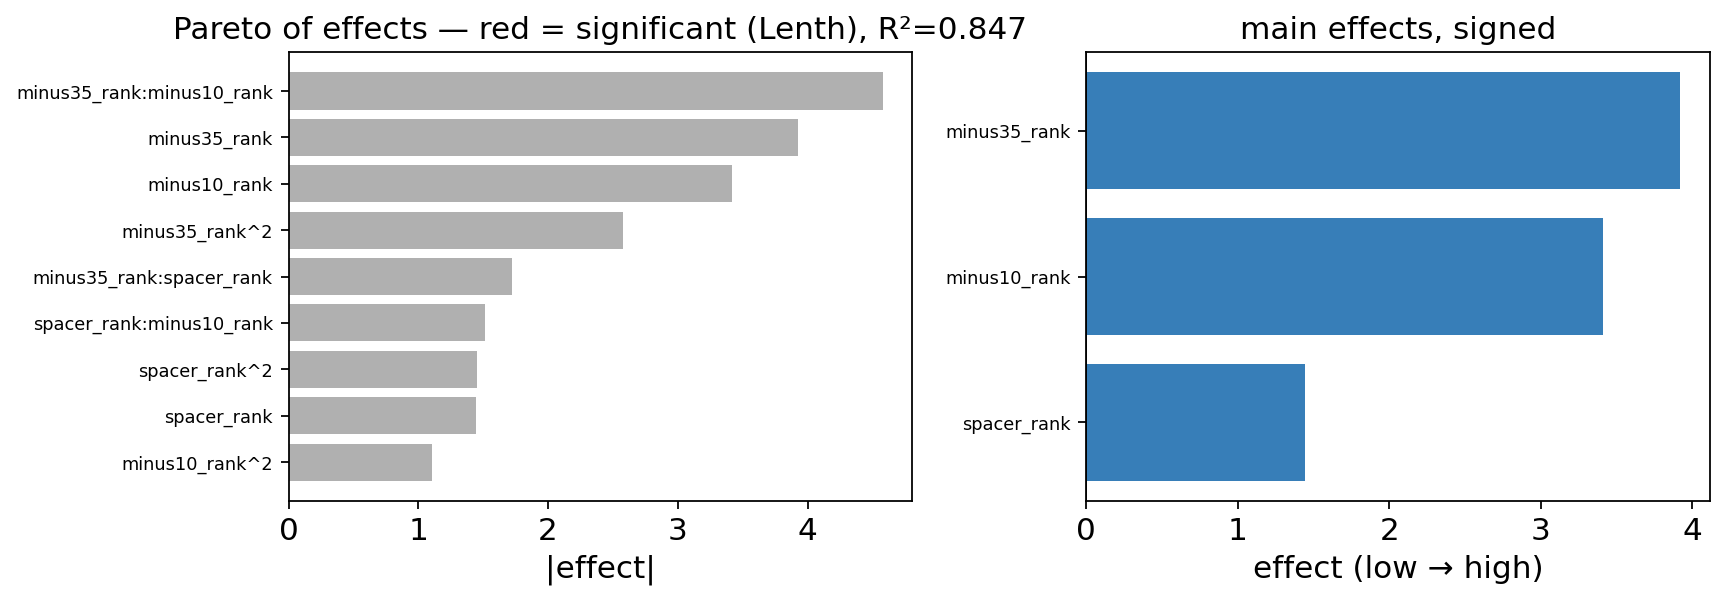

In [11]:
ov.synbio.plot_doe_effects(effects)
None

**The largest effect is an interaction**, not a main effect: `minus35 × minus10`
at +4.58 against +3.92 for the strongest main effect. That is the same finding
tutorial 07 reaches from the other direction — 30% of the variance in this library
is interaction, which is why the additive optimum there ranks 77th of 512. A
screening design that reports only main effects would have missed the biggest
term on the page.

The Pareto ordering is the output of a screening round — a ranking, not a table.
Significance uses **Lenth's method**: a screening design usually has no
replication and therefore no independent error estimate, so the pseudo-standard
error is built from the median of the small effects, on the reasoning that most
factors in a screen do nothing.

Two cautions the function reports rather than hides. Read `effects.notes`.

In [12]:
for note in effects.notes:
    print(' -', note)

 - Lenth PSE = 2.583,显著阈值 |effect| > 6.457(筛选设计通常无重复,故不用 t 检验)
 - 已估计 3 个二次项 —— 响应面设计的意义所在。


## 4 — Proposing the next batch

A Gaussian process over what has been measured, and the next experiments chosen
by expected improvement. This is the arrow from Learn back to Design.

In [13]:
proposal = ov.synbio.bayesian_optimize(np.asarray(screen.to_frame())[usable],
                                       np.asarray(response)[usable],
                                       rank_factors, batch=4, acquisition='ei', seed=0)
print(proposal)
print(proposal.to_frame().round(3).to_string())

Proposal(4 experiments, ei, best so far 3.184)
           minus35_rank  spacer_rank  minus10_rank  predicted  uncertainty     ei
proposal1         6.664        6.892         4.218      3.538        0.978  0.586
proposal2         6.840        6.984         5.309      3.519        0.882  0.538
proposal3         6.799        6.826         4.909      3.640        0.104  0.446
proposal4         6.788        6.324         4.691      3.595        0.065  0.401


Check `model_r_squared` before reading the proposals. A Gaussian process that
cannot reproduce its own training data is proposing at random, and the function
says so in its notes rather than leaving the number to be found.

In [14]:
print('GP R² on the observed data:', round(proposal.model_r_squared, 3))
for note in proposal.notes:
    print(' -', note)

GP R² on the observed data: 1.0


The four proposals are four *different* points. That is not automatic: a naive
batch asks for the current optimum four times over. A constant-liar pass refits
the model with each pick pinned at its posterior mean before choosing the next,
which is what spreads them out.

`ei` balances exploration against exploitation, `ucb` lets you set the balance
with `kappa`, and `greedy` is pure exploitation — which belongs only in a final
confirmation round.

## 5 — The campaign

What makes it a cycle rather than a line: it holds every round, conditions each
proposal on all of them, and answers "are we still improving".

In [15]:
campaign = ov.synbio.dbtl_campaign(rank_factors, objective='log2_expression')
campaign.record(np.asarray(screen.to_frame())[usable], np.asarray(response)[usable],
                note='round 1: central composite over rank space')
print(campaign)
print('best so far:', {k: round(v, 2) for k, v in campaign.best[1].items()})

DBTLCampaign(1 rounds, 17 experiments, best log2_expression=3.184, improving=True)
best so far: {'minus35_rank': np.float64(7.0), 'spacer_rank': np.float64(3.5), 'minus10_rank': np.float64(3.5)}


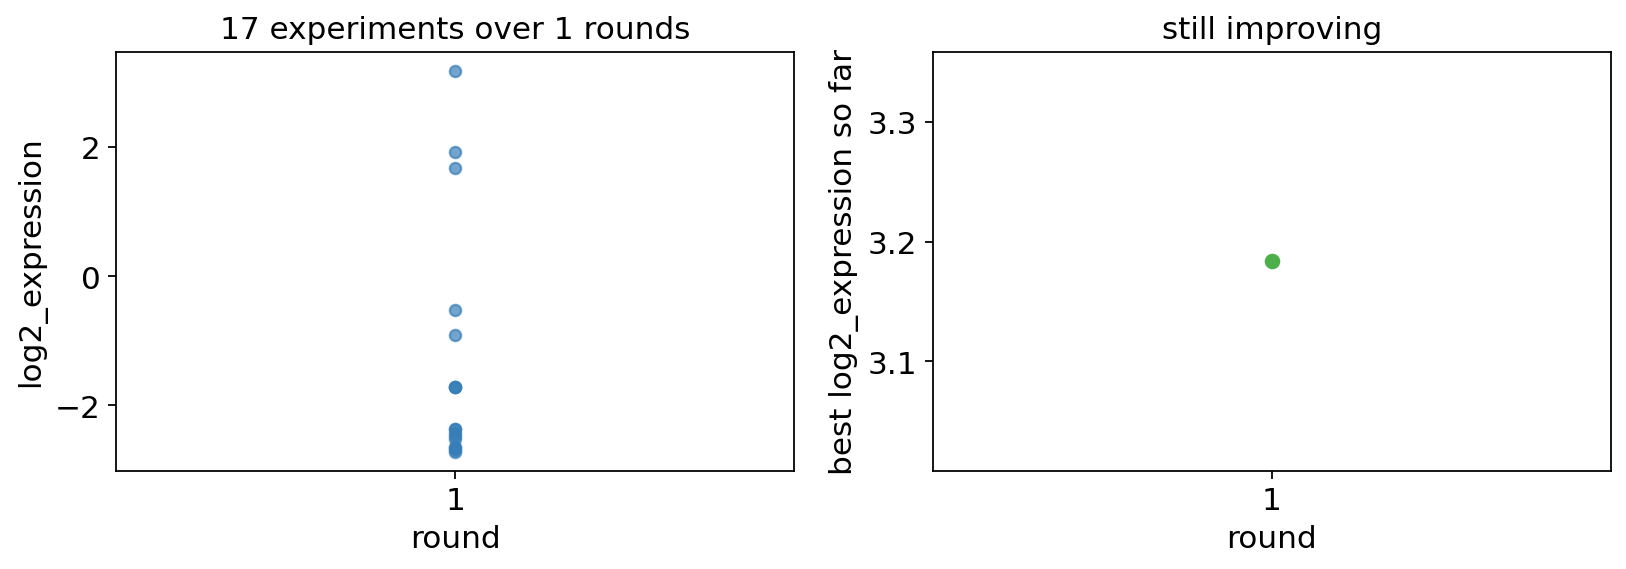

In [16]:
ov.synbio.plot_optimization_progress(campaign)
None

## 6 — When the factors are not really continuous

`orthogonal_array` is the bridge. If the "continuous" factor is really a choice
among k discrete settings — which it usually is, once you look at what the
pipette can actually deliver — a strength-2 array covers every *pair* of levels
in q² runs instead of q^k.

In [17]:
array = ov.synbio.orthogonal_array(4, 3)
print('4 levels, 3 factors:', array.shape[0], 'runs against', 4 ** 3, 'for the full grid')
print(array[:6])

4 levels, 3 factors: 16 runs against 64 for the full grid
[[0 0 0]
 [1 1 1]
 [2 2 2]
 [3 3 3]
 [0 1 2]
 [1 0 3]]


In [18]:
pairs = np.zeros((4, 4), dtype=int)
for row in array:
    pairs[row[0], row[1]] += 1
print('every (factor 1, factor 2) level pair appears exactly this many times:')
print(pairs)

every (factor 1, factor 2) level pair appears exactly this many times:
[[1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]
 [1 1 1 1]]


Every pair exactly once. That is what "strength 2" means, and it is what makes
main-effect estimates mutually uncorrelated — the same guarantee resolution IV
gives for two-level factors, generalised to any prime-power number of levels.

## What to carry away

**Match the machinery to the factor.** Continuous designs for quantities you can
dial (temperature, inducer, pH, feed rate); `combinatorial_design` and
`propose_combinations` from tutorial 07 for choices out of a parts box. An
optimiser that proposes a setting you cannot set has wasted the round.

**Look at the design in natural units before you build it.** The rotatable α puts
axial points outside the range you declared unless the design is rescaled — which
produced negative plasmid copy numbers before it was fixed.

**Read the diagnostics the functions return.** `analyse_doe` reports when no
interactions were estimable and when no quadratic terms could be fitted;
`bayesian_optimize` reports its own R² and warns when the surrogate has not
learned anything. Both are printed here rather than left in the object.